In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("/content/banner_interactions.csv")

print(f" dataframe head : {df.head()}")
print(f" dataframe shape : {df.shape}")
print(f" dataframe info : {df.info()}")



 dataframe head :    event_date  user_id banner_id  impressions  clicks  ctr
0  2026-01-01  u_00007    b_0082            3       0  0.0
1  2026-01-01  u_00009    b_0234            3       0  0.0
2  2026-01-01  u_00012    b_0041            4       0  0.0
3  2026-01-01  u_00012    b_0215            5       1  0.2
4  2026-01-01  u_00015    b_0210            5       2  0.4
 dataframe shape : (149911, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149911 entries, 0 to 149910
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   event_date   149911 non-null  object 
 1   user_id      149911 non-null  object 
 2   banner_id    149911 non-null  object 
 3   impressions  149911 non-null  int64  
 4   clicks       149911 non-null  int64  
 5   ctr          149911 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 6.9+ MB
 dataframe info : None


In [138]:
df['clicks'] = LabelEncoder().fit_transform(df['clicks'])
y = df['clicks']
x = df.drop(['clicks', 'user_id'], axis = 1)

imputer = SimpleImputer(strategy='most_frequent')
x = pd.DataFrame(imputer.fit_transform(x), columns=x.columns)

for col in x.columns:
  if x[col].dtype == 'object':
    x[col] = LabelEncoder().fit_transform(x[col])
  else:
    x[col] = StandardScaler().fit_transform(x[col].values.reshape(-1, 1))


In [139]:
y.value_counts()

,count
clicks,
0,132323
1,16070
2,1406
3,107
4,5


In [140]:
smote = SMOTE(random_state=42, k_neighbors=4) # Set k_neighbors to be less than or equal to the smallest class size - 1
x, y= smote.fit_resample(x, y)

In [141]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(529292, 4)
(132323, 4)
(529292,)
(132323,)


In [142]:
y.value_counts()

,count
clicks,
0,132323
1,132323
2,132323
3,132323
4,132323


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


Text(0.5, 1.0, 'Confusion Matrix')

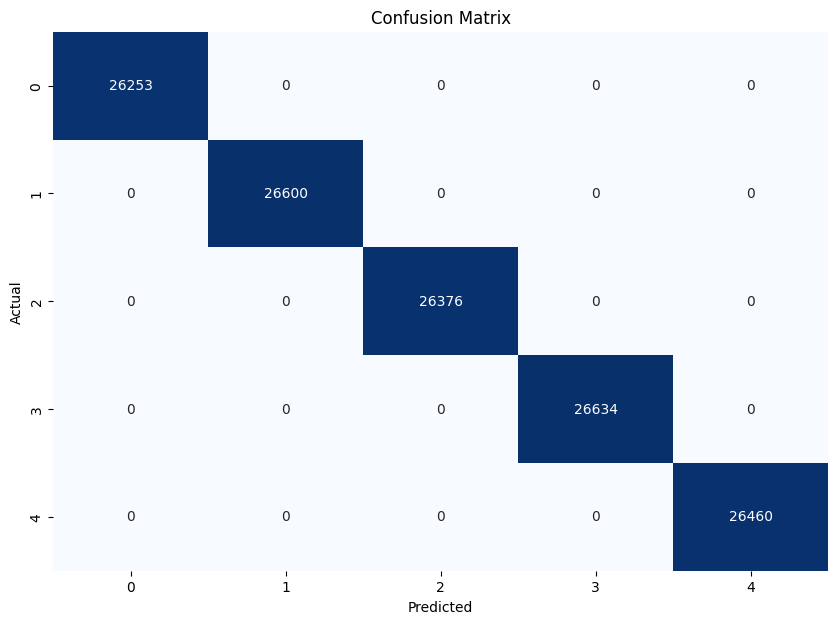

In [143]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize XGBoost Regressor model
xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    n_jobs=-1,
    verbose = True)

# Train the model
xgb.fit(x_train, y_train)

# Make predictions on the test set
y_pred = xgb.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Plotting actual vs. predicted values
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

In [144]:
import joblib

joblib.dump(xgb_model, "xg boost model")
print("Model saved as xg boost ")

Model saved as xg boost 
